pip install pandas


In [29]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [30]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [31]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
#Cargamos la base 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


# Rutas principales


PROJECT_DIR = Path.cwd()

ORANGE_BOOK_DIR = PROJECT_DIR / "orange_book"
DATA_INTERMEDIATE_DIR = PROJECT_DIR / "data_intermediate"
DATA_FINAL_DIR = PROJECT_DIR / "data_final"
FIGURES_DIR = PROJECT_DIR / "figures"
TABLES_DIR = PROJECT_DIR / "tables"

for folder in [DATA_INTERMEDIATE_DIR, DATA_FINAL_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(exist_ok=True)


# Funciones auxiliares


def clean_column_name(col):
    """
    Convierte nombres de columnas a formato snake_case sencillo.
    """
    col = col.strip()
    col = col.replace(";", "_")
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    return col.lower()


def standardize_columns(df):
    """
    Estandariza nombres de columnas.
    """
    out = df.copy()
    out.columns = [clean_column_name(c) for c in out.columns]
    return out


def normalize_appl_no(x):
    """
    Normaliza número de aplicación FDA a texto de 6 dígitos.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\.0$", "", x)
    x = re.sub(r"\D", "", x)
    if x == "":
        return np.nan
    return x.zfill(6)


def normalize_product_no(x):
    """
    Normaliza número de producto FDA a texto de 3 dígitos.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\.0$", "", x)
    x = re.sub(r"\D", "", x)
    if x == "":
        return np.nan
    return x.zfill(3)


def read_text_table(path, sep, encoding="latin1"):
    """
    Lee una tabla de texto conservando columnas como texto.
    """
    return pd.read_csv(
        path,
        sep=sep,
        dtype=str,
        encoding=encoding,
        low_memory=False
    )



# Cargar base analítica preliminar


survival_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v1.parquet"

survival_v1 = pd.read_parquet(survival_path)


# Cargar archivos de Orange Book


ob_patent = read_text_table(ORANGE_BOOK_DIR / "patent.txt", sep="~")
ob_exclusivity = read_text_table(ORANGE_BOOK_DIR / "exclusivity.txt", sep="~")

ob_patent = standardize_columns(ob_patent)
ob_exclusivity = standardize_columns(ob_exclusivity)

# Normalizar llaves
for df in [ob_patent, ob_exclusivity]:
    df["appl_no"] = df["appl_no"].apply(normalize_appl_no)
    df["product_no"] = df["product_no"].apply(normalize_product_no)

print("=" * 80)
print("Archivos cargados correctamente")
print("=" * 80)

print(f"survival_v1:     {survival_v1.shape[0]:,} filas | {survival_v1.shape[1]:,} columnas")
print(f"ob_patent:       {ob_patent.shape[0]:,} filas | {ob_patent.shape[1]:,} columnas")
print(f"ob_exclusivity:  {ob_exclusivity.shape[0]:,} filas | {ob_exclusivity.shape[1]:,} columnas")

print("\nColumnas de survival_v1:")
print(list(survival_v1.columns))

print("\nColumnas de ob_patent:")
print(list(ob_patent.columns))

print("\nColumnas de ob_exclusivity:")
print(list(ob_exclusivity.columns))

Archivos cargados correctamente
survival_v1:     1,439 filas | 23 columnas
ob_patent:       20,858 filas | 10 columnas
ob_exclusivity:  2,054 filas | 5 columnas

Columnas de survival_v1:
['ingredient', 'dosage_form', 'route', 'nme_approval_date', 'approval_year', 'innovator_appl_no', 'innovator_product_no', 'innovator_trade_name', 'first_generic_approval_date', 'first_generic_appl_no', 'first_generic_product_no', 'first_generic_trade_name', 'first_generic_te_code', 'event', 'end_date', 'time_to_generic_years', 'n_nda_products', 'n_nda_applications', 'n_anda_products_total', 'n_anda_applications_total', 'ingredient_key', 'dosage_form_key', 'route_key']

Columnas de ob_patent:
['appl_type', 'appl_no', 'product_no', 'patent_no', 'patent_expire_date_text', 'drug_substance_flag', 'drug_product_flag', 'patent_use_code', 'delist_flag', 'submission_date']

Columnas de ob_exclusivity:
['appl_type', 'appl_no', 'product_no', 'exclusivity_code', 'exclusivity_date']


La base cargó perfectmente y podemos decir que tiene 1439 filas con 23 columnas, a su vez tambien se cargaron del Orange book Ob patent con 20,858 filas con 10 columnas y Ob_exclusivity con 2054 filas y 5 columnas 


La llave que permitirá integrar estas tablas con survival_v1 será:

innovator_appl_no con appl_no;
innovator_product_no con product_no.

## Limpieza

Antes de integrar patentes y exclusividades hay que cambiar a formato fecha sino presentaremos errores.
De hecho lo podemos ver arriba pues ob_patentes viene como patent_expire_date_text y en exclusividades viene como exclusivity_date por lo tanto hay que homogenizarlas 

La siguiente celda hará lo siguiente:

convertir ambas columnas a formato datetime;
contar cuántas fechas se pudieron convertir;
revisar el rango temporal de expiraciones;
mostrar ejemplos de fechas problemáticas, si existen.


    
Esta revisión es importante porque las fechas de expiración se usarán para construir variables como:
fecha mínima de expiración de patente;
fecha máxima de expiración de patente;
años desde aprobación hasta expiración máxima de patente;
fecha máxima de expiración de exclusividad;
años desde aprobación hasta expiración máxima de exclusividad.

In [33]:
ob_patent = ob_patent.copy() 
ob_exclusivity = ob_exclusivity.copy() 

# Crea una nueva columna para la fecha de expiración de patentes en formato datetime
ob_patent["patent_expire_date"] = pd.to_datetime(
    ob_patent["patent_expire_date_text"], # Toma el texto original de la fecha
    errors="coerce"                       # Si un texto es inválido le pone un nulo (NaT)
)

# Crea una nueva columna para la fecha de submission de la patente 
ob_patent["submission_date_parsed"] = pd.to_datetime(
    ob_patent["submission_date"],         
    errors="coerce"                       # Si hay errores la convierte en nulo (NaT)
)

# Crea una nueva columna para la fecha de expiración de la exclusividad 
ob_exclusivity["exclusivity_date_parsed"] = pd.to_datetime(
    ob_exclusivity["exclusivity_date"],   
    errors="coerce"                       
)


print("=" * 80) 
print("Patentes: conversión de fechas") 
print("=" * 80) 

# Total de filas de la tabla de patentes, separando los miles con comas
print(f"Registros totales: {len(ob_patent):,}") 
# .sum() e imprime cuántas fechas de expiración de patentes SÍ son válidas (.notna())
print(f"Fechas de expiración convertidas: {ob_patent['patent_expire_date'].notna().sum():,}") 
# Cuenta cuántas fechas fallaron y quedaron como valores nulos (.isna())
print(f"Fechas de expiración no convertidas: {ob_patent['patent_expire_date'].isna().sum():,}") 

print("\nRango de expiración de patentes:") 
#la fecha de expiración de patente más antigua
print("Mínima:", ob_patent["patent_expire_date"].min()) 
#fecha de expiración de patente más lejana hacia el futuro
print("Máxima:", ob_patent["patent_expire_date"].max()) 

print("\nFechas de patente no convertidas más frecuentes:") 
print(
    ob_patent.loc[                                 #Usa .loc para filtrar la base de patentes
        ob_patent["patent_expire_date"].isna(),    #solo selecciona filas donde la fecha quedó nula
        "patent_expire_date_text"                  #Extrae solo la columna con el texto original que causó el error
    ]
    .value_counts(dropna=False)                    #Cuenta cuántas veces se repite exactamente el mismo error
    .head(20)                                     
    .rename_axis("patent_expire_date_text")        #Le asigna un título a la columna que contiene los textos originales
    .reset_index(name="n")                         #Aplana los datos como una tabla normal y nombra "n" a la columna de conteo
)


print("\n" + "=" * 80) 
print("Exclusividades: conversión de fechas") 
print("=" * 80) 

print(f"Registros totales: {len(ob_exclusivity):,}") 
#cuántas exclusividades lograron convertirse en fechas correctamente
print(f"Fechas de exclusividad convertidas: {ob_exclusivity['exclusivity_date_parsed'].notna().sum():,}") 
#cuántas exclusividades tenían texto basura y no pudieron convertirse
print(f"Fechas de exclusividad no convertidas: {ob_exclusivity['exclusivity_date_parsed'].isna().sum():,}") 

print("\nRango de expiración de exclusividades:") 
print("Mínima:", ob_exclusivity["exclusivity_date_parsed"].min()) 
print("Máxima:", ob_exclusivity["exclusivity_date_parsed"].max()) 

print("\nFechas de exclusividad no convertidas más frecuentes:") 
print(
    ob_exclusivity.loc[                                 
        ob_exclusivity["exclusivity_date_parsed"].isna(),#agarra solo las filas donde la conversión falló (NaT)
        "exclusivity_date"                              #Extrae el texto que la computadora no entendió
    ]
    .value_counts(dropna=False)                         #Agrupa y cuenta cuántas veces apareció cada texto problemático
    .head(20)                                           
    .rename_axis("exclusivity_date")                    #Nombra la primera columna de la tabla de resultados
    .reset_index(name="n")                              #Convierte a DataFrame y nombra la columna de repeticiones como "n"
)


Patentes: conversión de fechas
Registros totales: 20,858
Fechas de expiración convertidas: 20,858
Fechas de expiración no convertidas: 0

Rango de expiración de patentes:
Mínima: 2025-07-13 00:00:00
Máxima: 2045-07-23 00:00:00

Fechas de patente no convertidas más frecuentes:
Empty DataFrame
Columns: [patent_expire_date_text, n]
Index: []

Exclusividades: conversión de fechas
Registros totales: 2,054
Fechas de exclusividad convertidas: 2,054
Fechas de exclusividad no convertidas: 0

Rango de expiración de exclusividades:
Mínima: 2022-03-06 00:00:00
Máxima: 2035-12-12 00:00:00

Fechas de exclusividad no convertidas más frecuentes:
Empty DataFrame
Columns: [exclusivity_date, n]
Index: []


Las fechas se convirtieron correctamente , tenemos en patente un total 20858 registros de una fecha de experimentacion valida y no tenemos fechas faltante, el rango de expiracion va de 2025 a 2045 y esto es una estimacion al furuto por eso tenemos esto años.


En la tabla de exclusividades, los 2,054 registros también tienen una fecha de expiración válida. El rango de expiración de exclusividades va de 2022-03-06 a 2035-12-12.


Una observación relevante es que las fechas de expiración disponibles en estos archivos corresponden al estado actual del Orange Book descargado. Por tanto, representan patentes y exclusividades actualmente listadas o vigentes en la versión de los datos utilizada, no necesariamente el historial completo de todas las patentes y exclusividades que pudieron haber existido en años anteriores.



## Agregación de información de patentes por producto 

La tabla ob_patent puede contener múltiples registros para una misma combinación de aplicación y producto. Esto ocurre porque un producto puede tener varias patentes listadas, por ejemplo patentes de sustancia activa, de producto farmacéutico, de formulación o de uso.

Para integrar esta información con la base de supervivencia, necesitamos resumir las patentes a nivel:

appl_no + product_no

En la siguiente celda se construirán variables agregadas como:

* n_patents: número de patentes listadas;
* patent_expiry_min: fecha mínima de expiración de patente;
*patent_expiry_max: fecha máxima de expiración de patente;
* has_drug_substance_patent: indicador de al menos una patente de sustancia;
* has_drug_product_patent: indicador de al menos una patente de producto;
* has_patent_use_code: indicador de al menos un código de uso de patente;
* has_delist_flag: indicador de al menos una patente con solicitud de delisting.


In [34]:
patent_product_summary = (
    ob_patent
    #Junta todas las filas que pertenezcan a la misma medicina exacta
    .groupby(["appl_no", "product_no"], dropna=False) 
    .agg(
        #cuenta Cuántas patentes únicas tiene este producto en total?
        n_patents=("patent_no", "nunique"), 
        
        # Cuántos registros (filas) ocupó en el libro original?
        n_patent_records=("patent_no", "size"), 
    
        #Encuentra la fecha de la patente que caduca primero (min) y la que caduca al último (max)
        patent_expiry_min=("patent_expire_date", "min"),
        patent_expiry_max=("patent_expire_date", "max"),
        
        #Tiene alguna patente que proteja la sustancia activa pura (el ingrediente)?
        has_drug_substance_patent=("drug_substance_flag", lambda x: x.astype(str).str.upper().eq("Y").any()),
        
        #alguna patente que proteja la forma en que se armó la pastilla o crema?
        has_drug_product_patent=("drug_product_flag", lambda x: x.astype(str).str.upper().eq("Y").any()),
        
        #patentes por descubrirle un uso médico nuevo a una medicina vieja?
        has_patent_use_code=("patent_use_code", lambda x: x.notna().any()),
        
        # usamos el Delisting. ¿Alguna de las  patentes fue invalidada o borrada?
        has_delist_flag=("delist_flag", lambda x: x.astype(str).str.upper().eq("Y").any()),
        
        #Guarda los códigos y números de patente separados por punto y coma por si ocupo despues
        patent_use_codes=("patent_use_code", lambda x: "; ".join(sorted(x.dropna().astype(str).unique()))),
        patent_numbers=("patent_no", lambda x: "; ".join(sorted(x.dropna().astype(str).unique())))
    )
    .reset_index()) 

In [35]:
#crea un boleano que si el producto tiene más de 0 patentes, y False si no tiene.
patent_product_summary["has_patent"] = patent_product_summary["n_patents"] > 0


print("=" * 80)
print("Resumen de patentes por appl_no + product_no")
print("=" * 80)

# Imprime el total de filas (total de productos)
print(f"Filas en resumen de patentes: {len(patent_product_summary):,}")
# Cuenta y muestra cuántos trámites (aplicaciones) distintos tienen al menos una patente
print(f"Aplicaciones únicas con patentes: {patent_product_summary['appl_no'].nunique():,}")
# Confirmaque no hay duplicados al contar la combinación de aplicación + producto
print(f"Productos únicos con patentes: {patent_product_summary[['appl_no', 'product_no']].drop_duplicates().shape[0]:,}")

print("\nResumen numérico de número de patentes por producto:")
#display muestra tablas en Jupyter de forma más bonita que 'print'
display(
    patent_product_summary["n_patents"]                   # Toma la columna que cuenta las patentes
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]) # Calcula promedio, mínimos, máximos y los percentiles indicados
    .to_frame(name="n_patents")                           # Lo convierte en un formato de tabla ordenado
)


print("\nDistribución de indicadores de patente:")
#nueva tabla 
patent_flags_summary = pd.DataFrame({
    # Primera columna
    "variable": [
        "has_drug_substance_patent", # Patente de sustancia
        "has_drug_product_patent",   # Patente de formulación
        "has_patent_use_code",       # Patente de uso médico
        "has_delist_flag"            # Patente invalidada (el VAR)
    ],
    # Segunda columna suma cuántos (verdaderos) hubo en cada categoría
    "n_true": [
        patent_product_summary["has_drug_substance_patent"].sum(),
        patent_product_summary["has_drug_product_patent"].sum(),
        patent_product_summary["has_patent_use_code"].sum(),
        patent_product_summary["has_delist_flag"].sum()
    ]
})

#tercera columna a la tabla calculando el porcentaje: (Total de True * 100) / Total de productos
patent_flags_summary["percent_true"] = (
    100 * patent_flags_summary["n_true"] / len(patent_product_summary)
)
display(patent_flags_summary)


print("\nEjemplos de productos con patentes:")
display(
    patent_product_summary
    .sort_values("n_patents", ascending=False) # Ordena la tabla fijándose en el número de patentes (de mayor a menor)
    .head(20)                                  
)

Resumen de patentes por appl_no + product_no
Filas en resumen de patentes: 2,588
Aplicaciones únicas con patentes: 1,309
Productos únicos con patentes: 2,588

Resumen numérico de número de patentes por producto:


,n_patents
count,2588.000000
mean,6.462133
std,7.755275
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
90%,14.000000
95%,20.000000
max,130.000000



Distribución de indicadores de patente:


,variable,n_true,percent_true
0,has_drug_substance_patent,1182,45.672334
1,has_drug_product_patent,2278,88.021638
2,has_patent_use_code,2050,79.211747
3,has_delist_flag,45,1.738794



Ejemplos de productos con patentes:


,appl_no,product_no,n_patents,n_patent_records,patent_expiry_min,patent_expiry_max,has_drug_substance_patent,has_drug_product_patent,has_patent_use_code,has_delist_flag,patent_use_codes,patent_numbers,has_patent
2128,215430,001,130,130,2033-10-29,2043-04-20,False,True,True,False,U-3419; U-3563; U-3778,10058518; 10064857; 10080727; 10092560; 100925...,True
2129,215431,001,82,82,2036-04-11,2045-03-10,False,True,True,False,U-1719; U-4133; U-4134; U-4135; U-4136; U-4356,10029010; 10058614; 10137131; 10195278; 102653...,True
1544,210563,004,70,110,2026-12-28,2036-09-03,True,True,True,False,U-1456; U-1491; U-1650; U-1684; U-1946; U-1947...,10004746; 10004746*PED; 10010507; 10010507*PED...,True
1541,210563,001,68,106,2026-12-28,2036-09-03,True,True,True,False,U-1491; U-1650; U-1684; U-1946; U-2159; U-2241...,10004746; 10004746*PED; 10010507; 10010507*PED...,True
939,205552,001,67,99,2026-12-28,2035-04-24,True,True,True,False,U-1491; U-1650; U-1683; U-1684; U-1745; U-1946...,10004746; 10004746*PED; 10016435; 10016435*PED...,True
1543,210563,003,66,104,2026-12-28,2036-09-03,True,True,True,False,U-1491; U-1650; U-1684; U-1946; U-2159; U-2241...,10004746; 10004746*PED; 10010507; 10010507*PED...,True
1542,210563,002,66,104,2026-12-28,2036-09-03,True,True,True,False,U-1491; U-1650; U-1684; U-1946; U-2159; U-2241...,10004746; 10004746*PED; 10010507; 10010507*PED...,True
940,205552,002,65,97,2026-12-28,2035-04-24,True,True,True,False,U-1491; U-1650; U-1684; U-1946; U-2159; U-2219...,10004746; 10004746*PED; 10016435; 10016435*PED...,True
1305,208623,001,63,64,2027-05-16,2042-01-11,True,False,True,True,U-2371; U-2372; U-2373,10076514; 10251873; 10383864; 10406143; 104710...,True
585,202057,001,62,65,2027-05-31,2033-06-28,False,True,True,False,U-1287; U-1478; U-2688; U-2689; U-2690; U-2691...,10010517; 10265287; 10278935; 10278936; 102789...,True


A partir de los 20,858 registros originales de patentes, se obtuvieron 2,588 productos únicos con al menos una patente listada. Estos productos corresponden a 1,309 aplicaciones únicas.

Como resultado obtuvimos un promedio de 6.46 patentes 
* min de 1 patente
*  percentil de 75 = 8 patentes
*  percentil de 90 = 14 patentes 
*  mediana de 4 patentes

En cuanto a los indicadores de tipo de patente, se observa que:

* 45.7% de los productos con patentes tienen al menos una patente de sustancia;
* 88.0% tienen al menos una patente de producto;
* 79.2% tienen al menos un código de uso de patente;
* 1.7% tienen al menos una patente con indicador de delisting.
* 
Estos indicadores serán útiles para comparar curvas de supervivencia y, posteriormente, construir modelos de riesgo. Por ejemplo, podremos evaluar si la presencia de patente de sustancia o una fecha máxima de expiración más lejana se asocia con mayor tiempo hasta la entrada de genéricos.



## Agregación de exclusividades por producto 

De forma analoga como lo hicimos con las patentes por producyo ahora lo haremos por exclusividades con el mismo  appl_no + product_no 
y en esta siguiente celda se resumira ob_exclu contruyendo nuevas variables 



In [36]:
exclusivity_product_summary = (
    ob_exclusivity
    .groupby(["appl_no", "product_no"], dropna=False)
    .agg(
        n_exclusivities=("exclusivity_code", "nunique"),
        n_exclusivity_records=("exclusivity_code", "size"),
        exclusivity_expiry_min=("exclusivity_date_parsed", "min"),
        exclusivity_expiry_max=("exclusivity_date_parsed", "max"),
        exclusivity_codes=("exclusivity_code", lambda x: "; ".join(sorted(x.dropna().astype(str).unique())))
    )
    .reset_index()
)

exclusivity_product_summary["has_exclusivity"] = exclusivity_product_summary["n_exclusivities"] > 0

# Indicadores exploratorios por patrones frecuentes de códigos.
# Estos patrones se revisarán más adelante con el diccionario oficial.
exclusivity_product_summary["has_nce_like_exclusivity"] = (
    exclusivity_product_summary["exclusivity_codes"]
    .astype(str)
    .str.contains(r"\bNCE\b", case=False, regex=True)
)

exclusivity_product_summary["has_orphan_like_exclusivity"] = (
    exclusivity_product_summary["exclusivity_codes"]
    .astype(str)
    .str.contains(r"\bODE\b|\bORPHAN\b", case=False, regex=True)
)

exclusivity_product_summary["has_pediatric_like_exclusivity"] = (
    exclusivity_product_summary["exclusivity_codes"]
    .astype(str)
    .str.contains(r"\*PED|\bPED\b", case=False, regex=True)
)

print("=" * 80)
print("Resumen de exclusividades por appl_no + product_no")
print("=" * 80)

print(f"Filas en resumen de exclusividades: {len(exclusivity_product_summary):,}")
print(f"Aplicaciones únicas con exclusividades: {exclusivity_product_summary['appl_no'].nunique():,}")
print(f"Productos únicos con exclusividades: {exclusivity_product_summary[['appl_no', 'product_no']].drop_duplicates().shape[0]:,}")

print("\nResumen numérico de número de exclusividades por producto:")
display(
    exclusivity_product_summary["n_exclusivities"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .to_frame(name="n_exclusivities")
)

print("\nCódigos de exclusividad más frecuentes en registros originales:")
display(
    ob_exclusivity["exclusivity_code"]
    .value_counts()
    .head(30)
    .rename_axis("exclusivity_code")
    .reset_index(name="n_records")
)

print("\nIndicadores exploratorios de exclusividad:")
excl_flags_summary = pd.DataFrame({
    "variable": [
        "has_nce_like_exclusivity",
        "has_orphan_like_exclusivity",
        "has_pediatric_like_exclusivity"
    ],
    "n_true": [
        exclusivity_product_summary["has_nce_like_exclusivity"].sum(),
        exclusivity_product_summary["has_orphan_like_exclusivity"].sum(),
        exclusivity_product_summary["has_pediatric_like_exclusivity"].sum()
    ]
})

excl_flags_summary["percent_true"] = (
    100 * excl_flags_summary["n_true"] / len(exclusivity_product_summary)
)

display(excl_flags_summary)

print("\nEjemplos de productos con exclusividades:")
display(
    exclusivity_product_summary
    .sort_values(["n_exclusivities", "exclusivity_expiry_max"], ascending=[False, False])
    .head(20)
) #literal es lo mismo solo que ahora para exclusividades 

Resumen de exclusividades por appl_no + product_no
Filas en resumen de exclusividades: 1,035
Aplicaciones únicas con exclusividades: 552
Productos únicos con exclusividades: 1,035

Resumen numérico de número de exclusividades por producto:


,n_exclusivities
count,1035.000000
mean,1.794203
std,1.138888
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
90%,3.000000
95%,4.000000
max,12.000000



Códigos de exclusividad más frecuentes en registros originales:


,exclusivity_code,n_records
0,NCE,362
1,PED,318
2,NPP,131
3,NP,128
4,ODE*,83
5,GAIN,42
6,M-14,41
7,CGT,30
8,M-82,14
9,I-958,12



Indicadores exploratorios de exclusividad:


,variable,n_true,percent_true
0,has_nce_like_exclusivity,363,35.072464
1,has_orphan_like_exclusivity,411,39.710145
2,has_pediatric_like_exclusivity,171,16.521739



Ejemplos de productos con exclusividades:


,appl_no,product_no,n_exclusivities,n_exclusivity_records,exclusivity_expiry_min,exclusivity_expiry_max,exclusivity_codes,has_exclusivity,has_nce_like_exclusivity,has_orphan_like_exclusivity,has_pediatric_like_exclusivity
496,213246,001,12,22,2027-05-08,2031-11-29,M-311; M-312; NPP; ODE-301; ODE-302; ODE-303; ...,True,False,True,True
497,213246,002,12,22,2027-05-08,2031-11-29,M-311; M-312; NPP; ODE-301; ODE-302; ODE-303; ...,True,False,True,True
669,215358,001,8,8,2026-10-29,2031-10-29,I-953; I-954; M-318; NCE; ODE-381; ODE-382; OD...,True,True,True,False
670,215358,002,8,8,2026-10-29,2031-10-29,I-953; I-954; M-318; NCE; ODE-381; ODE-382; OD...,True,True,True,False
233,207500,001,7,12,2022-03-06,2031-06-08,GAIN; NPP; ODE-305; ODE-454; ODE-458; ODE-90; PED,True,False,True,True
235,207501,001,7,12,2022-03-06,2031-06-08,GAIN; NPP; ODE-305; ODE-453; ODE-459; ODE-90; PED,True,False,True,True
494,213217,001,7,7,2026-01-19,2031-03-07,I-817; I-936; ODE-274; ODE-276; ODE-370; ODE-3...,True,False,True,False
318,209939,001,6,6,2026-06-05,2031-08-30,D-189; I-916; NPP; ODE-423; ODE-495; ODE-497,True,False,True,False
319,209939,002,6,6,2026-06-05,2031-08-30,D-189; I-916; NPP; ODE-423; ODE-495; ODE-497,True,False,True,False
320,209940,001,6,6,2026-06-05,2031-08-30,D-189; I-916; NPP; ODE-423; ODE-495; ODE-497,True,False,True,False


De 2054 pasamos a 1035 filas en resumen de exclusividades

A su vez obtuvimos un promedio de 1.79 exclusividad
* percentil de 90 = 3 exclisividades
* minimo de 1 exclusividad
* maximo de 12 exclusividades
* y una mediana de  1 exclusividad



Los códigos de exclusividad más frecuentes fueron NCE, PED, NPP, NP, ODE* y GAIN. Esto confirma que la tabla contiene categorías regulatorias relevantes para el proyecto, incluyendo exclusividad de nueva entidad química, exclusividad pediátrica, exclusividad huérfana y designaciones especiales.

Los indicadores exploratorios muestran que, entre los productos con exclusividades:

aproximadamente 35.1% tienen un código tipo NCE;
aproximadamente 39.7% tienen un código asociado a exclusividad huérfana u ODE;
aproximadamente 16.5% tienen un código pediátrico o relacionado con PED.

Sea:
* NCE (New Chemical Entity): Otorga 5 años de exclusividad legal para medicamentos cuya molécula activa es completamente nueva en el mercado.

* PED (Pediatric Exclusivity): Bono de 6 meses (180 días) extra de protección que se suma al vencimiento de otras patentes por realizar estudios clínicos en niños.

* NPP (New Patient Population): Otorga 3 años de exclusividad al comprobar que un medicamento ya existente también es útil para un nuevo grupo demográfico (ej. de adultos a adolescentes).

* NP (New Product): Otorga 3 años de exclusividad por desarrollar una nueva presentación (ej. cambiar de pastilla a parche) que haya requerido nuevos ensayos clínicos.

* ODE (Orphan Drug Exclusivity con asterisco):* Escudo de 7 años para tratamientos de enfermedades muy raras.

* GAIN (Generating Antibiotic Incentives Now): Otorga 5 años extra (acumulables con otras exclusividades) por desarrollar tratamientos contra bacterias u hongos graves y resistentes.

## Integración de patentes y exclusividades con la base de supervivencia 

En esta sección se integrarán los resúmenes de patentes y exclusividades con la base survival_v1.

La unión se realizará usando las llaves del producto innovador:

innovator_appl_no -> appl_no innovator_product_no -> product_no

Después de la unión, los productos sin patentes o exclusividades listadas recibirán valores adecuados:

has_patent = False;
n_patents = 0;
has_exclusivity = False;
n_exclusivities = 0.

También se construirán variables temporales derivadas:
años desde aprobación hasta expiración mínima de patente;
años desde aprobación hasta expiración máxima de patente;
años desde aprobación hasta expiración máxima de exclusividad.
Estas variables serán útiles para análisis descriptivos, curvas Kaplan--Meier por subgrupos y modelos Cox/AFT.



In [37]:
survival_v2 = survival_v1.copy() 

survival_v2["innovator_appl_no"] = survival_v2["innovator_appl_no"].apply(normalize_appl_no) # Aplica formato de 6 dígitos a la aplicación
survival_v2["innovator_product_no"] = survival_v2["innovator_product_no"].apply(normalize_product_no) # Aplica formato de 3 dígitos al producto

patent_for_merge = patent_product_summary.copy() #Copia del resumen de patentes para prepararlo para la unión
patent_for_merge = patent_for_merge.rename(columns={ # Renombra columnas para que coincidan exactamente con la base maestra
    "appl_no": "innovator_appl_no", # Cambia appl_no a innovator_appl_no
    "product_no": "innovator_product_no"}) # Cambia product_no a innovator_product_no

survival_v2 = survival_v2.merge( # Une la base maestra con el resumen de patentes
    patent_for_merge, # Tabla secundaria a unir
    on=["innovator_appl_no", "innovator_product_no"], #las llaves puente para hacer el cruce exacto
    how="left") 

excl_for_merge = exclusivity_product_summary.copy() # Copia el resumen de exclusividades
excl_for_merge = excl_for_merge.rename(columns={ 
    "appl_no": "innovator_appl_no", # Iguala el nombre de la aplicación
    "product_no": "innovator_product_no"}) # Iguala el nombre del producto

survival_v2 = survival_v2.merge( # Une la base ya con patentes con las exclusividades
    excl_for_merge, #tabla secundaria de exclusividades
    on=["innovator_appl_no", "innovator_product_no"], # Llaves de cruce
    how="left") 

for col in ["n_patents", "n_patent_records", "n_exclusivities", "n_exclusivity_records"]: # Recorre las columnas de conteos
    if col in survival_v2.columns: # Verifica que la columna exista en la base
        survival_v2[col] = survival_v2[col].fillna(0).astype(int) # Rellena los vacíos (NaN) con 0 y los convierte a enteros

bool_cols = [ #lista con todas las columnas de indicadores de "Sí/No"
    "has_patent",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_delist_flag",
    "has_exclusivity",
    "has_nce_like_exclusivity",
    "has_orphan_like_exclusivity",
    "has_pediatric_like_exclusivity"]

for col in bool_cols: # Recorre cada columna booleana de la lista anterior
    if col in survival_v2.columns: # Verifica si la columna existe en la tabla fusionada
        survival_v2[col] = survival_v2[col].fillna(False).astype(bool) # Cambia los vacíos (NaN) por False y asegura el formato booleano

for col in ["patent_use_codes", "patent_numbers", "exclusivity_codes"]: # Recorre las columnas que contienen texto/listas
    if col in survival_v2.columns: # Checa si existen en la tabla
        survival_v2[col] = survival_v2[col].fillna("") # Rellena los espacios vacíos con texto en blanco en lugar de NaN

date_cols = [ # Agrupa las columnas que deben tratarse como fechas
    "nme_approval_date",
    "patent_expiry_min",
    "patent_expiry_max",
    "exclusivity_expiry_min",
    "exclusivity_expiry_max"]

for col in date_cols: # Recorre las columnas de fechas
    if col in survival_v2.columns: # Verifica que estén en la base
        survival_v2[col] = pd.to_datetime(survival_v2[col], errors="coerce") # Fuerza la conversión a formato fecha y anula los errores

survival_v2["years_to_patent_expiry_min"] = ( # Crea nueva columna para el tamaño mínimo del monopolio en años
    (survival_v2["patent_expiry_min"] - survival_v2["nme_approval_date"]).dt.days / 365.25) # Resta fecha expiración mín menos fecha aprobación y divide entre días del año

survival_v2["years_to_patent_expiry_max"] = ( # Crea nueva columna para la máxima duración teórica de la patente
    (survival_v2["patent_expiry_max"] - survival_v2["nme_approval_date"]).dt.days / 365.25) # Calcula diferencia en años considerando años bisiestos (.25)

survival_v2["years_to_exclusivity_expiry_max"] = ( # Crea columna para el tamaño del escudo de exclusividad FDA
    (survival_v2["exclusivity_expiry_max"] - survival_v2["nme_approval_date"]).dt.days / 365.25) # Resta expiración exclusividad menos aprobación y pasa a años

print("=" * 80)
print("Base survival_v2 con patentes y exclusividades")
print("=" * 80)

print(f"Filas: {survival_v2.shape[0]:,}") # Imprime la cantidad final de filas en la base 
print(f"Columnas: {survival_v2.shape[1]:,}") # Imprime la cantidad final de columnas de la base

integration_summary = pd.DataFrame({ # Crea una tabla desde cero para resumir los cruces
    "variable": [ # Define los nombres de las filas del resumen
        "has_patent",
        "has_exclusivity",
        "has_drug_substance_patent",
        "has_drug_product_patent",
        "has_patent_use_code",
        "has_nce_like_exclusivity",
        "has_orphan_like_exclusivity",
        "has_pediatric_like_exclusivity"
    ],
    "n_true": [ # Suma cuántos (True) hay para cada tipo de barrera
        survival_v2["has_patent"].sum(), # Cuenta cuántos tienen cualquier patente
        survival_v2["has_exclusivity"].sum(), # Cuenta cuántos tienen cualquier exclusividad
        survival_v2["has_drug_substance_patent"].sum(), # Cuenta cuántos patentaron la sustancia
        survival_v2["has_drug_product_patent"].sum(), # Cuenta cuántos patentaron la forma física
        survival_v2["has_patent_use_code"].sum(), # Cuenta cuántos patentaron el uso
        survival_v2["has_nce_like_exclusivity"].sum(), # Cuenta cuántos tienen exclusividad NCE
        survival_v2["has_orphan_like_exclusivity"].sum(), # Cuenta cuántos tienen exclusividad Huérfana
        survival_v2["has_pediatric_like_exclusivity"].sum() # Cuenta cuántos tienen exclusividad Pediátrica
    ]})

integration_summary["percent_true"] = 100 * integration_summary["n_true"] / len(survival_v2) # Agrega columna calculando el porcentaje del total
display(integration_summary) # Muestra en pantalla la tabla resumen de integración

print("\nResumen de variables numéricas regulatorias:")
display( 
    survival_v2[ # Selecciona solo las columnas de conteo y tiempo del dataframe
        [
            "n_patents",
            "n_exclusivities",
            "years_to_patent_expiry_min",
            "years_to_patent_expiry_max",
            "years_to_exclusivity_expiry_max"
        ]
    ].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])) # Calcula media, percentiles y extremos para esas variables

print("\nPrimeras filas enriquecidas:")
display(
    survival_v2[ #columnas clave para verificar visualmente que el cruce funcionó
        [
            "ingredient", "dosage_form", "route",
            "nme_approval_date", "event", "time_to_generic_years",
            "has_patent", "n_patents", "patent_expiry_max",
            "has_exclusivity", "n_exclusivities", "exclusivity_codes",
            "exclusivity_expiry_max"
        ]
    ].head(20)) 

Base survival_v2 con patentes y exclusividades
Filas: 1,439
Columnas: 46


/tmp/ipykernel_12955/3777752394.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survival_v2[col] = survival_v2[col].fillna(False).astype(bool) # Cambia los vacíos (NaN) por False y asegura el formato booleano
/tmp/ipykernel_12955/3777752394.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survival_v2[col] = survival_v2[col].fillna(False).astype(bool) # Cambia los vacíos (NaN) por False y asegura el formato booleano
/tmp/ipykernel_12955/3777752394.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and w

,variable,n_true,percent_true
0,has_patent,589,40.931202
1,has_exclusivity,150,10.423905
2,has_drug_substance_patent,264,18.346074
3,has_drug_product_patent,504,35.024322
4,has_patent_use_code,473,32.870049
5,has_nce_like_exclusivity,9,0.625434
6,has_orphan_like_exclusivity,68,4.725504
7,has_pediatric_like_exclusivity,51,3.544128



Resumen de variables numéricas regulatorias:


,n_patents,n_exclusivities,years_to_patent_expiry_min,years_to_patent_expiry_max,years_to_exclusivity_expiry_max
count,1439.000000,1439.000000,589.000000,589.000000,150.000000
mean,2.719249,0.200834,15.500786,18.709984,13.743938
std,6.028016,0.697182,4.767716,4.270507,4.048465
min,0.000000,0.000000,7.323751,8.008214,7.427789
25%,0.000000,0.000000,11.920602,16.002738,10.611910
50%,0.000000,0.000000,14.568104,18.652977,13.337440
75%,3.000000,0.000000,18.757016,20.941821,15.656400
90%,8.000000,1.000000,21.201916,23.451335,17.885832
95%,13.000000,2.000000,23.479808,25.454346,22.529911
max,68.000000,7.000000,39.912389,39.912389,29.894593



Primeras filas enriquecidas:


,ingredient,dosage_form,route,nme_approval_date,event,time_to_generic_years,has_patent,n_patents,patent_expiry_max,has_exclusivity,n_exclusivities,exclusivity_codes,exclusivity_expiry_max
0,ABACAVIR SULFATE,SOLUTION,ORAL,1998-12-17,1,17.776865,False,0,NaT,False,0,,NaT
1,ABACAVIR SULFATE,TABLET,ORAL,1998-12-17,1,13.503080,False,0,NaT,False,0,,NaT
2,ABACAVIR SULFATE; DOLUTEGRAVIR SODIUM; LAMIVUDINE,TABLET,ORAL,2014-08-22,0,11.630390,True,4,2030-06-08,True,2,M-294; PED,2026-12-15
3,ABACAVIR SULFATE; LAMIVUDINE,TABLET,ORAL,2004-08-02,1,12.158795,False,0,NaT,False,0,,NaT
4,ABACAVIR SULFATE; LAMIVUDINE; ZIDOVUDINE,TABLET,ORAL,2000-11-14,1,13.056810,False,0,NaT,False,0,,NaT
5,ABALOPARATIDE,SOLUTION,SUBCUTANEOUS,2017-04-28,0,8.947296,True,9,2040-01-10,False,0,,NaT
6,ABEMACICLIB,TABLET,ORAL,2017-09-28,0,8.528405,True,1,2031-09-28,False,0,,NaT
7,ABIRATERONE ACETATE,TABLET,ORAL,2011-04-28,1,7.509925,False,0,NaT,False,0,,NaT
8,ACALABRUTINIB,CAPSULE,ORAL,2017-10-31,0,8.438056,True,9,2036-07-01,True,2,I-960; ODE-274,2028-01-16
9,ACAMPROSATE CALCIUM,"TABLET, DELAYED RELEASE",ORAL,2004-07-29,1,8.963723,False,0,NaT,False,0,,NaT


En esta nueva base V2 tenemos o se consideraron 1439 unidades/filas del v1 pero ahora contiene 46 columnas 
En la cohorte enriquecida se observa que:

* 589 unidades tienen al menos una patente listada, equivalente a 40.9% de la base.
* 150 unidades tienen al menos una exclusividad listada, equivalente a 10.4%.
* 264 unidades tienen patente de sustancia, equivalente a 18.3%.
* 504 unidades tienen patente de producto, equivalente a 35.0%.
* 473 unidades tienen código de uso de patente, equivalente a 32.9%.
* 9 unidades tienen exclusividad tipo NCE según la clasificación exploratoria.
* 68 unidades tienen exclusividad tipo huérfana u ODE.
* 51 unidades tienen exclusividad pediátrica o relacionada con PED.

Estos datos que obtuvimos nos dan la base para ya comparalo con curvas de supervivencia pero por subgrupos regulatorios. por ejemplo con patente vs sin patente.Sin embargo, debe recordarse que las patentes y exclusividades provienen de la versión actual del Orange Book. Por lo tanto, estas variables reflejan la información listada al momento de descarga, no necesariamente el historial completo de protección regulatoria desde la fecha original de aprobación.



## Comparación descriptiva por presencia de patentes y exclusicidades 
En esta celda se compararán los grupos:

* con patente vs sin patente;
* con exclusividad vs sin exclusividad;
* con patente de sustancia vs sin patente de sustancia;
* con patente de producto vs sin patente de producto;
* con código de uso de patente vs sin código de uso de patente.

Para cada grupo se calculará:
* número de unidades;
* número de eventos observados;
* proporción de eventos;
* mediana del tiempo hasta genérico o censura;
* mediana del tiempo hasta genérico entre eventos observados.

Esta comparación es únicamente descriptiva. No debe interpretarse todavía como evidencia causal, porque los grupos pueden diferir en año de aprobación, tipo de producto, ruta, clase terapéutica y otras características.


In [38]:
def summarize_by_binary_group(df, group_col): #función que resume los datos usando una variable de Verdadero/Falso
    summary = ( 
        df 
        .groupby(group_col) # Agrupa los datos separando los que tienen el(True) de los que no (False)
        .agg( # Abre el bloque para calcular múltiples estadísticas al mismo tiempo
            n_units=("event", "size"), # Cuenta el número total de medicamentos en cada grupo
            n_events=("event", "sum"), # Suma cuántos monopolios ya cayeron (tienen evento = 1)
            event_rate=("event", "mean"), # Calcula qué porcentaje del grupo ya perdió exclusividad
            median_time_or_followup=("time_to_generic_years", "median"), # Calcula la mediana global de tiempo (mezclando vivos y caídos)
            mean_time_or_followup=("time_to_generic_years", "mean"), # Calcula el promedio global de tiempo 
            median_approval_year=("approval_year", "median") # Calcula en qué año fue aprobado el medicamento típico del grupo
        ) 
        .reset_index() 
    )
    
    med_events = ( #solo en el tiempo real de exclusividad
        df.loc[df["event"].eq(1)] # Filtra la base para quedarse ÚNICAMENTE con los que ya tienen genérico
        .groupby(group_col)["time_to_generic_years"] # Agrupa a estos caídos dependiendo si tenían el true o no 
        .median() # Calcula la mediana de tiempo de vida exclusivamente para los que ya perdieron
        .rename("median_time_events_only") 
        .reset_index()
    ) 
    
    summary = summary.merge(med_events, on=group_col, how="left") # Une la tabla principal con la columna de medianas reales
    summary["group_variable"] = group_col #columna extra 
    
    return summary[
        [ 
            "group_variable", group_col, "n_units", "n_events", "event_rate", # Primero las identificaciones y conteos
            "median_time_or_followup", "median_time_events_only", # Luego las medianas de tiempo (global y real)
            "mean_time_or_followup", "median_approval_year" # Finalmente el promedio y el año de aprobación
        ] 
    ]

group_cols = [ 
    "has_patent", # ¿tiene cualquier patente registrada?
    "has_exclusivity", # tiene cualquier exclusividad de la FDA?
    "has_drug_substance_patent", #patentó químicamente el ingrediente puro?
    "has_drug_product_patent", #patentó la forma de la pastilla/crema?
    "has_patent_use_code",
    "has_nce_like_exclusivity", # obtuvo de 5 años por nueva entidad química?
    "has_orphan_like_exclusivity", #7 años por enfermedad rara?
    "has_pediatric_like_exclusivity"] #6 meses por pruebas en niños?

#todas estas que estan aqui son mis 8 protecciones legales digamos 

descriptive_group_tables = {} #diccionario vacío

for col in group_cols: # Inicia un ciclo 
    descriptive_group_tables[col] = summarize_by_binary_group(survival_v2, col) #aplica la función de arriba y guarda la tabla en el diccionario
    print("=" * 80)
    print(f"Resumen por {col}")
    print("=" * 80)
    display(descriptive_group_tables[col])

Resumen por has_patent


,group_variable,has_patent,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_patent,False,850,618,0.727059,10.847365,8.702259,11.870232,2004.0
1,has_patent,True,589,241,0.409168,9.916496,7.764545,10.441907,2014.0


Resumen por has_exclusivity


,group_variable,has_exclusivity,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_exclusivity,False,1289,797,0.618309,10.469541,8.317591,11.456967,2007.0
1,has_exclusivity,True,150,62,0.413333,9.184120,8.826831,9.813005,2015.0


Resumen por has_drug_substance_patent


...

,group_variable,has_nce_like_exclusivity,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_nce_like_exclusivity,False,1430,859,0.600699,10.342231,8.372348,11.305846,2008.0
1,has_nce_like_exclusivity,True,9,0,0.000000,7.789185,NaN,8.069055,2018.0


Resumen por has_orphan_like_exclusivity


,group_variable,has_orphan_like_exclusivity,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_orphan_like_exclusivity,False,1371,833,0.607586,10.376454,8.36961,11.361775,2008.0
1,has_orphan_like_exclusivity,True,68,26,0.382353,8.991102,9.09514,9.749809,2015.0


Resumen por has_pediatric_like_exclusivity


,group_variable,has_pediatric_like_exclusivity,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_pediatric_like_exclusivity,False,1388,832,0.599424,10.303901,8.351814,11.313630,2008.0
1,has_pediatric_like_exclusivity,True,51,27,0.529412,10.412047,9.582478,10.522795,2014.0


no todos los medicamentos de la lista de has patent tienen una patente que los proteja. De tus 1,439 medicamentos, 850 salieron con has_patent = False. Esto no significa que sean un error de los datos, sino que refleja cómo funciona la ley
Y esto pasa por diferentes causas como, muchos de esos 850 medicamentos del grupo False sí tuvieron patentes en el pasado, pero como ya son viejos y sus patentes caducaron, ya no aparecen en el archivo actual de la FDA. Por eso, el 72% de ellos ya perdió la exclusividad y tiene genéricos. 
Y lo mismo sucede con las exclusividades por esto mismo lo que sigue es comparar con curvas Kaplan meier 

In [39]:
pip install lifelines 

Note: you may need to restart the kernel to use updated packages.


Curvas Kaplan--Meier: has_patent
Figura guardada en: /home/violeta/Escritorio/Patentes/figures/km_by_has_patent.png


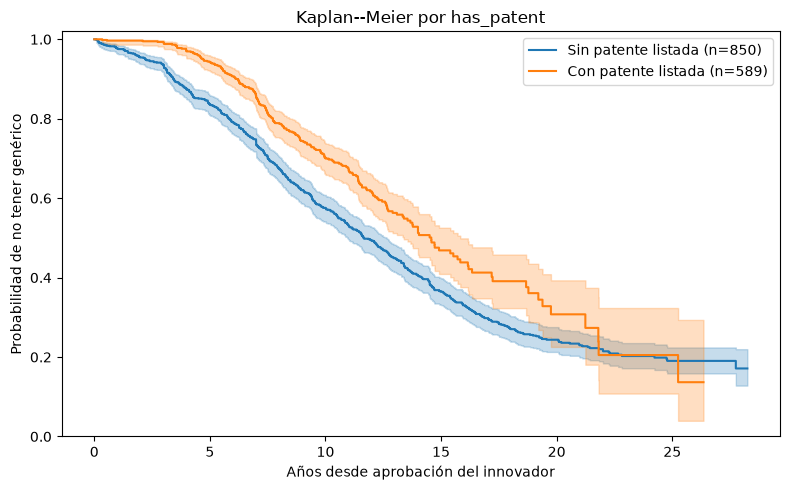

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_patent,850,589,618,241,11.646817,14.576318,23.339173,0.000001


Curvas Kaplan--Meier: has_exclusivity
Figura guardada en: /home/violeta/Escritorio/Patentes/figures/km_by_has_exclusivity.png


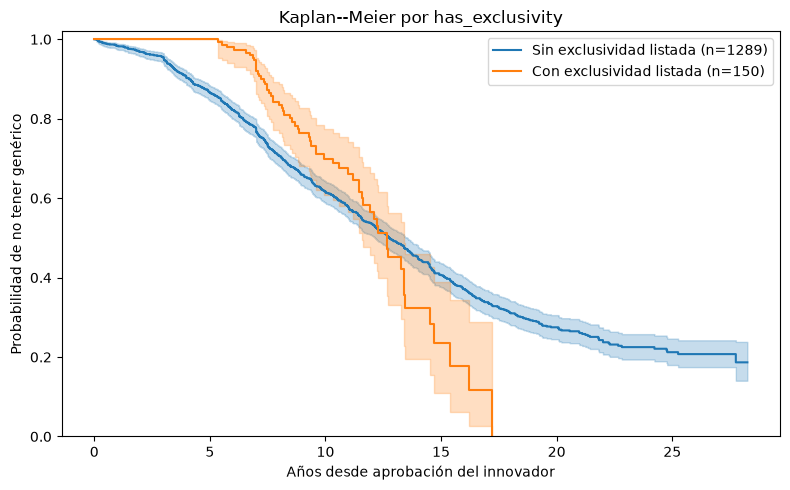

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_exclusivity,1289,150,797,62,12.758385,12.640657,0.887236,0.346227


Curvas Kaplan--Meier: has_drug_substance_patent
Figura guardada en: /home/violeta/Escritorio/Patentes/figures/km_by_drug_substance_patent.png


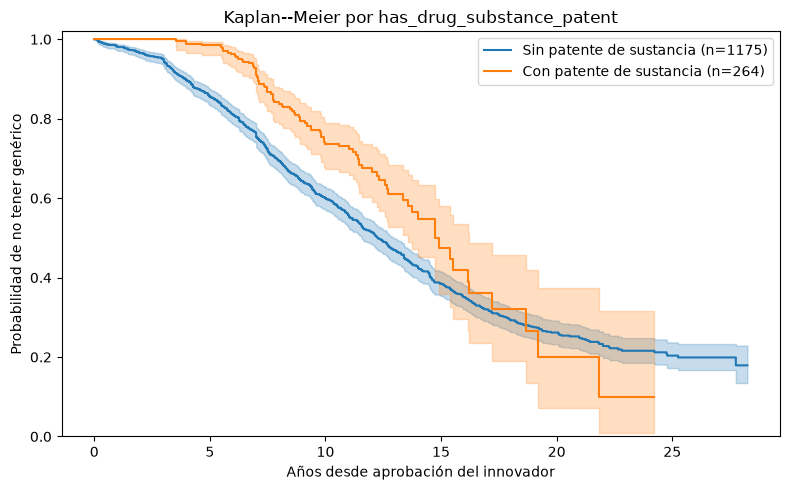

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_drug_substance_patent,1175,264,769,90,12.246407,14.724162,17.293805,0.000032


Curvas Kaplan--Meier: has_drug_product_patent
Figura guardada en: /home/violeta/Escritorio/Patentes/figures/km_by_drug_product_patent.png


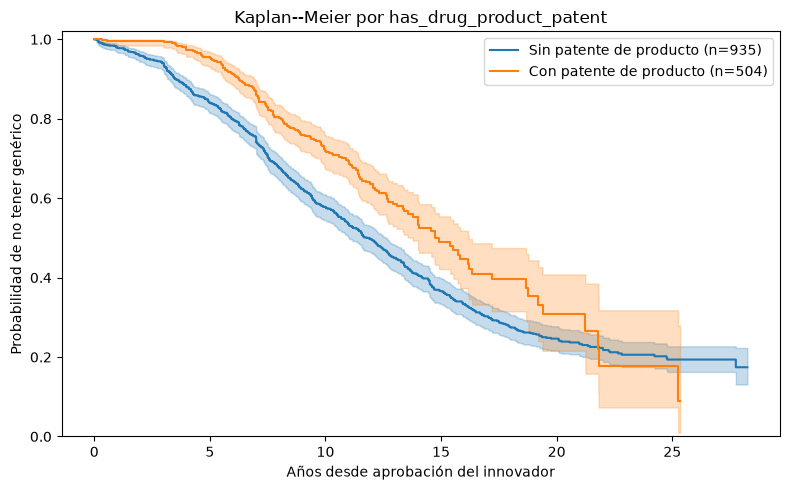

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_drug_product_patent,935,504,667,192,11.78371,14.724162,25.254709,5.023677e-07


Curvas Kaplan--Meier: has_patent_use_code
Figura guardada en: /home/violeta/Escritorio/Patentes/figures/km_by_patent_use_code.png


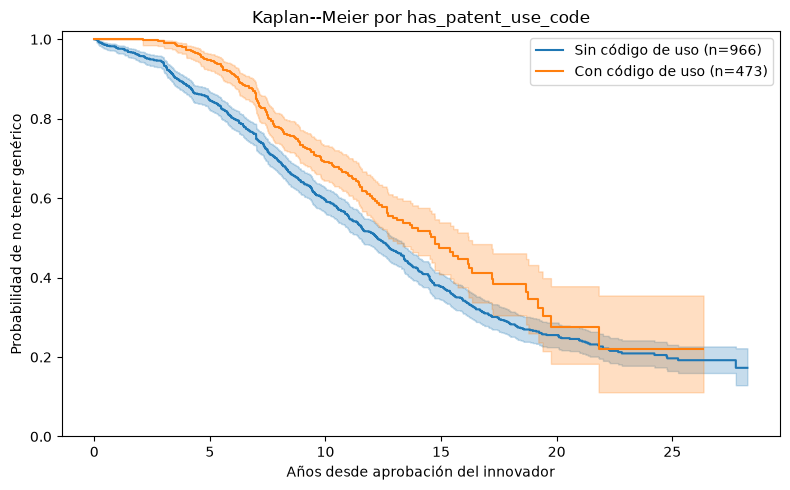

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_patent_use_code,966,473,667,192,12.246407,14.715948,14.3135,0.000155


Resumen global de comparaciones Kaplan--Meier


,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_patent,850,589,618,241,11.646817,14.576318,23.339173,1.358058e-06
1,has_exclusivity,1289,150,797,62,12.758385,12.640657,0.887236,3.462273e-01
2,has_drug_substance_patent,1175,264,769,90,12.246407,14.724162,17.293805,3.202292e-05
3,has_drug_product_patent,935,504,667,192,11.783710,14.724162,25.254709,5.023677e-07
4,has_patent_use_code,966,473,667,192,12.246407,14.715948,14.313500,1.547511e-04


In [40]:
from lifelines import KaplanMeierFitter #herramienta matemática para crear las curvas de supervivencia
from lifelines.statistics import logrank_test # Importa la prueba estadística para comparar si dos curvas son genuinamente diferentes

def plot_km_by_binary_group(df, group_col, label_false=None, label_true=None, filename=None): # Define la función que hará la gráfica y calculará la prueba
    label_false = label_false or f"{group_col} = False" # Asigna un texto por defecto para la etiqueta del grupo sin escudo
    label_true = label_true or f"{group_col} = True" # Asigna un texto por defecto para la etiqueta del grupo con escudo
    
    data_false = df.loc[df[group_col].eq(False)].copy() # Filtra y aísla los datos exclusivos de los medicamentos sin protección
    data_true = df.loc[df[group_col].eq(True)].copy() # Filtra y aísla los datos exclusivos de los medicamentos con protección
    
    kmf_false = KaplanMeierFitter()
    kmf_true = KaplanMeierFitter() 
    
    fig, ax = plt.subplots(figsize=(8, 5)) 
    
    kmf_false.fit( 
        durations=data_false["time_to_generic_years"], # Le entrega la columna con los tiempos de vida
        event_observed=data_false["event"], # Le entrega la columna de quién ya murió y quién sobrevive
        label=f"{label_false} (n={len(data_false)})" # Nombra la curva indicando el tamaño de este grupo
    )
    kmf_false.plot_survival_function(ax=ax, ci_show=True) # Dibuja la curva y el área sombreada (margen de error)
    
    kmf_true.fit( 
        durations=data_true["time_to_generic_years"], # Le entrega los tiempos de vida del grupo 
        event_observed=data_true["event"], # Le entrega los eventos de este grupo
        label=f"{label_true} (n={len(data_true)})" # Nombra la segunda curva indicando cuántos medicamentos tiene
    )
    kmf_true.plot_survival_function(ax=ax, ci_show=True) # Empalma esta segunda curva en el mismo lienzo para poder compararlas
    
    ax.set_xlabel("Años desde aprobación del innovador") 
    ax.set_ylabel("Probabilidad de no tener genérico") 
    ax.set_title(f"Kaplan--Meier por {group_col}") 
    ax.set_ylim(0, 1.02) 
    
    plt.tight_layout() 
    
    if filename is not None: 
        fig_path = FIGURES_DIR / filename # Construye la ruta exacta hacia la carpeta de gráficas
        plt.savefig(fig_path, dpi=300, bbox_inches="tight") # Guarda el archivo en alta resolución sin excesos de margen blanco
        print(f"Figura guardada en: {fig_path}") 
    
    plt.show() 
    
    result = logrank_test( # Ejecuta la prueba Log-Rank para saber si las curvas son distintas por realidad o por azar
        data_false["time_to_generic_years"], # Manda los tiempos del grupo desprotegido
        data_true["time_to_generic_years"], # Manda los tiempos del grupo protegido
        event_observed_A=data_false["event"], # Manda las muertes/censuras del grupo desprotegido
        event_observed_B=data_true["event"] # Manda las muertes/censuras del grupo protegido
    )
    
    summary = pd.DataFrame({ # Arma una tabla para presentar los resultados de esta prueba estadística
        "group_col": [group_col], # Guarda el nombre de la variable analizada
        "n_false": [len(data_false)], # Guarda cuántos no tenían la variable
        "n_true": [len(data_true)], # Guarda cuántos sí la tenían
        "events_false": [data_false["event"].sum()], # Guarda cuántos perdieron exclusividad sin 
        "events_true": [data_true["event"].sum()], # Guarda cuántos perdieron exclusividad con
        "km_median_false": [kmf_false.median_survival_time_], # Guarda la esperanza (mediana KM) que calculó la curva para el grupo sin 
        "km_median_true": [kmf_true.median_survival_time_], # Guarda la mediana de supervivencia calculada para el grupo con 
        "logrank_statistic": [result.test_statistic], # Guarda el puntaje numérico de la prueba estadística
        "logrank_p_value": [result.p_value] # Guarda el p-value (si es menor a 0.05, significa que las curvas sí son diferentes estadísticamente)
    })
    
    return summary 

km_group_summaries = [] 

comparisons = [ # Crea un índice con los 5 que se van a graficar, sus nombres para las líneas, y el nombre del archivo
    ("has_patent", "Sin patente listada", "Con patente listada", "km_by_has_patent.png"),
    ("has_exclusivity", "Sin exclusividad listada", "Con exclusividad listada", "km_by_has_exclusivity.png"),
    ("has_drug_substance_patent", "Sin patente de sustancia", "Con patente de sustancia", "km_by_drug_substance_patent.png"),
    ("has_drug_product_patent", "Sin patente de producto", "Con patente de producto", "km_by_drug_product_patent.png"),
    ("has_patent_use_code", "Sin código de uso", "Con código de uso", "km_by_patent_use_code.png"),
]

for group_col, label_false, label_true, filename in comparisons: 
    print("=" * 80)
    print(f"Curvas Kaplan--Meier: {group_col}")
    print("=" * 80)
    
    summary = plot_km_by_binary_group( 
        survival_v2, # Usa la base de datos completa enriquecida
        group_col=group_col, # Indica qué variable toca analizar en este ciclo
        label_false=label_false,
        label_true=label_true, 
        filename=filename # Aplica el nombre del archivo para exportarlo a la carpeta
    )
    
    display(summary) 
    km_group_summaries.append(summary) # Mete esa tabla en la caja vacía que cree arriba

km_group_summary_table = pd.concat(km_group_summaries, ignore_index=True) # Saca todas las tablas de la caja y las pega una sobre otra en un solo documento

print("=" * 80)
print("Resumen global de comparaciones Kaplan--Meier")
print("=" * 80)
display(km_group_summary_table) 

### Interpretación de Curvas Kaplan-Meier

La generación de estas curvas nos permite visualizar la probabilidad de que un medicamento mantenga su monopolio a lo largo del tiempo.

#### Curva
* **Eje Y (Probabilidad):** Inicia en 1.0 (100% de los medicamentos mantienen su exclusividad). Las caídas (los "escalones") representan el momento exacto en que un genérico logra entrar al mercado.
* **Eje X (Años):** Representa el tiempo transcurrido desde la fecha de aprobación original de la nueva entidad molecular (NME).
* **Área Sombreada:** Intervalos de confianza al 95%. Se ensanchan hacia el final del eje X debido a que quedan menos medicamentos "sobrevivientes" bajo observación, aumentando la incertidumbre estadística.

---

#### Caracteristicas 

**Patente Listada vs. Sin Patente (`has_patent`)**
* **Visualización:** La curva del grupo con patente se mantiene visiblemente por encima de la curva sin patente (azul) durante la mayor parte del seguimiento.
* **Estadística:** La prueba log-rank es altamente significativa (p ≈ 1.36e-06). 
* **Conclusión:** Tener al menos una patente registrada retrasa efectivamente la entrada de genéricos. La mediana de supervivencia aumenta en casi 3 años (14.58 años con patente vs. 11.65 años sin patente).

**Exclusividad Listada vs. Sin Exclusividad (`has_exclusivity`)**
* **Visualización:** Las curvas se entrelazan y sus intervalos de confianza se empalman por completo. 
* **Estadística:** La prueba log-rank no es significativa (p = 0.346).
* **Conclusión:** Bajo esta comparación general, las exclusividades administrativas de la FDA (agrupadas) no muestran una ventaja global clara en el tiempo de supervivencia frente a los medicamentos que no las poseen. Las medianas son casi idénticas (12.76 vs. 12.64 años).

**Sustancia, Producto y Uso)**
* **Visualización:** Las gráficas de `drug_substance_patent`, `drug_product_patent` y `patent_use_code` muestran un patrón casi idéntico, donde el grupo protegido domina fuertemente la supervivencia.
* **Estadística:** En los tres casos, la prueba log-rank arroja valores p pequeñisimas, confirmando diferencias estadísticas rotundas.
* **Conclusión:** La mediana de supervivencia para los que poseen estas patentes es idéntica en las tres categorías: **14.72 años**. Esto sugiere la presencia de *patent thickets , donde los laboratorios blindan sus medicamentos de alto valor comercial con múltiples capas de protección simultáneas (protegiendo el químico, la pastilla y el uso al mismo tiempo).

---

####  El Sesgo del Tiempo

Aunque estos resultados son una excelente primera evidencia exploratoria de que las patentes prolongan los monopolios, deben interpretarse con cautela estadística. 

El método Kaplan-Meier es estrictamente **univariado** y no controla por posibles factores de confusión. Existe un fuerte sesgo temporal en los datos: los medicamentos clasificados "sin patente" son predominantemente fármacos más antiguos cuyas patentes ya expiraron y fueron removidas de la versión actual del *Orange Book*. Por el contrario, los medicamentos "con patente" pertenecen a cohortes más recientes que aún no han tenido tiempo cronológico suficiente para enfrentar competencia genérica masiva. 

Para aislar el verdadero efecto de cada patente eliminando el "ruido" de la fecha de aprobación y otras variables (ruta de administración, clase terapéutica), el siguiente paso analítico es ajustar estos datos mediante un modelo multivariado, como el **Modelo de Riesgos Proporcionales de Cox**.

Guardado de la base enriquecida y tablas de resumen
Después de integrar patentes y exclusividades y generar las primeras comparaciones Kaplan--Meier por subgrupos, guardaremos los principales resultados de este notebook.

Se guardarán tres salidas:

La base enriquecida survival_v2, que contiene el endpoint de supervivencia junto con variables de patentes y exclusividades.
La tabla integration_summary, que resume la presencia de variables regulatorias en la cohorte.
La tabla km_group_summary_table, que resume las comparaciones Kaplan--Meier por subgrupos.
Estos archivos permitirán continuar en el siguiente notebook con modelos Cox o AFT sin tener que repetir toda la ingesta y agregación regulatoria.

In [41]:
# Rutas de salida
survival_v2_parquet_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v2_patents_exclusivities.parquet"
survival_v2_csv_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v2_patents_exclusivities.csv"

integration_summary_path = TABLES_DIR / "integration_summary_patents_exclusivities.csv"
km_group_summary_path = TABLES_DIR / "km_group_summary_patents_exclusivities.csv"

# Guardar base enriquecida
survival_v2.to_parquet(survival_v2_parquet_path, index=False)
survival_v2.to_csv(survival_v2_csv_path, index=False)

# Guardar tablas resumen
integration_summary.to_csv(integration_summary_path, index=False)
km_group_summary_table.to_csv(km_group_summary_path, index=False)

print("=" * 80)
print("Archivos guardados correctamente")
print("=" * 80)

print("Base enriquecida:")
print(f"Parquet: {survival_v2_parquet_path}")
print(f"CSV:     {survival_v2_csv_path}")

print("\nTablas resumen:")
print(f"Integración regulatoria: {integration_summary_path}")
print(f"Comparaciones KM:        {km_group_summary_path}")

print("\nDimensiones de survival_v2:")
print(f"Filas: {survival_v2.shape[0]:,}")
print(f"Columnas: {survival_v2.shape[1]:,}")

Archivos guardados correctamente
Base enriquecida:
Parquet: /home/violeta/Escritorio/Patentes/data_intermediate/survival_analysis_v2_patents_exclusivities.parquet
CSV:     /home/violeta/Escritorio/Patentes/data_intermediate/survival_analysis_v2_patents_exclusivities.csv

Tablas resumen:
Integración regulatoria: /home/violeta/Escritorio/Patentes/tables/integration_summary_patents_exclusivities.csv
Comparaciones KM:        /home/violeta/Escritorio/Patentes/tables/km_group_summary_patents_exclusivities.csv

Dimensiones de survival_v2:
Filas: 1,439
Columnas: 46


Se generaron ambos el csv y el parquet , de igual forma como en el primer notebook el parquet sera la fuente principal para trabajar con Python.

También se guardaron dos tablas resumen:

integration_summary_patents_exclusivities.csv, con la frecuencia de variables regulatorias como presencia de patentes, exclusividades, patentes de sustancia, patentes de producto y códigos de uso.
km_group_summary_patents_exclusivities.csv, con las medianas Kaplan--Meier y pruebas log-rank para las comparaciones por subgrupos.
La base final de este notebook conserva:

1,439 unidades ingrediente--forma--ruta;
46 columnas;
endpoint de supervivencia;
variables de patentes;
variables de exclusividades;
variables temporales derivadas.